
# Braille Vision - Complete A to Z Project

This notebook covers:

1. Import Libraries
2. Load Dataset
3. Visualize Data
4. Train/Test Split
5. Build CNN Model
6. Train Model
7. Save Model
8. Predict Single Character
9. Translate Braille Sentence Image
10. Convert Output to Speech
11. Deploy with Tkinter GUI

Dataset structure expected:

```
hackathon/
│
├── A/
├── B/
├── C/
...
├── Z/
└── space/
```


In [1]:
!pip install tensorflow opencv-python pillow matplotlib scikit-learn pyttsx3


In [2]:
pip install charset-normalizer

Note: you may need to restart the kernel to use updated packages.


In [3]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


C:\Users\Tejveer Singh\.conda\envs\braille\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
import os

DATASET_PATH = r'C:\Users\Tejveer Singh\Desktop\main\hackathon\data'

print(os.listdir(DATASET_PATH))


['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [5]:
IMG_SIZE = 64

images = []
labels = []

classes = sorted(os.listdir(DATASET_PATH))

for label, folder in enumerate(classes):

    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)
            labels.append(label)

        except Exception as e:
            print(img_path)
            print(e)

images = np.array(images)
labels = np.array(labels)

print("Total Images:", len(images))
print("Classes:", classes)


Total Images: 14974
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


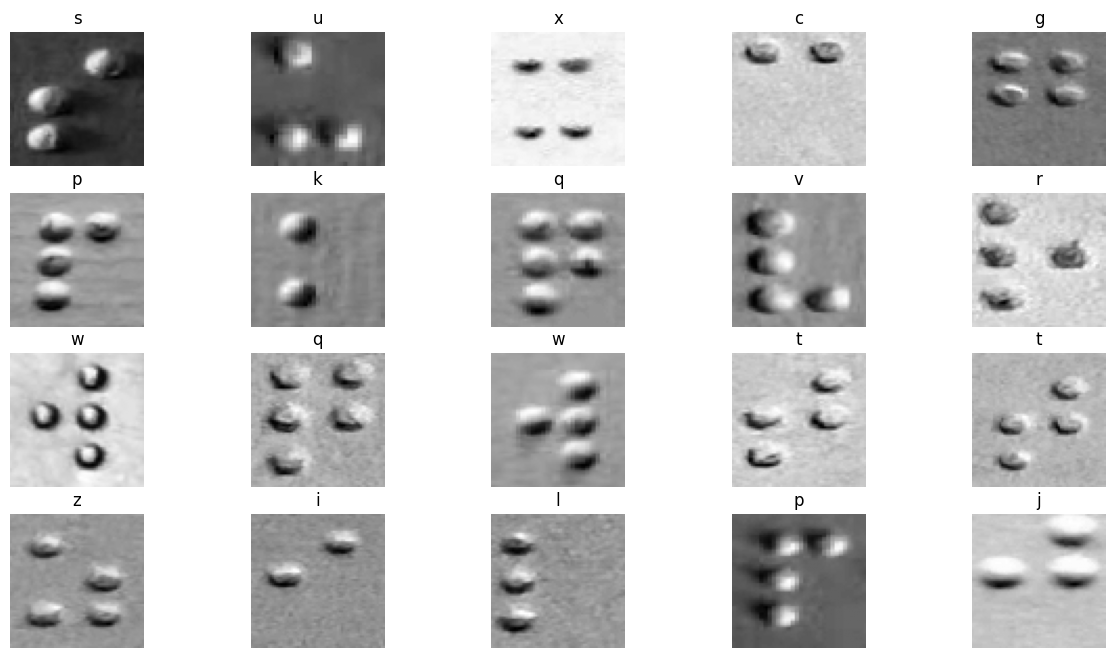

In [6]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for i in range(20):

    idx = random.randint(0, len(images)-1)

    plt.subplot(4,5,i+1)
    plt.imshow(images[idx], cmap='gray')
    plt.title(classes[labels[idx]])
    plt.axis('off')

plt.show()

In [7]:
images = images / 255.0

images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

y = to_categorical(labels)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(11979, 64, 64, 1)
(2995, 64, 64, 1)


In [9]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,1)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(classes),activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\Tejveer Singh\.conda\envs\braille\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           6,682 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,279,258 (4.88 MB)

 Trainable params: 1,279,258 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5145 - loss: 1.7026 - val_accuracy: 0.9666 - val_loss: 0.2028
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9334 - loss: 0.2402 - val_accuracy: 0.9790 - val_loss: 0.1126
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9553 - loss: 0.1528 - val_accuracy: 0.9846 - val_loss: 0.1019
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.9706 - loss: 0.1061 - val_accuracy: 0.9880 - val_loss: 0.0894
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.9715 - loss: 0.0937 - val_accuracy: 0.9883 - val_loss: 0.0797
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.9769 - loss: 0.0768 - val_accuracy: 0.9866 - val_loss: 0.0736
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9775 - loss: 0.0706 - val_accuracy: 0.9883 - val_loss: 0.0804
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.9817 - loss: 0.0648 - 

In [11]:
model.save('model.h5')
print("Model Saved")


Model Saved


In [12]:
loss, acc = model.evaluate(X_test,y_test)

print("Accuracy:", acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9900 - loss: 0.0660
Accuracy: 0.989983320236206


In [13]:
model = load_model('model.keras')

def predict_character(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img,(64,64))
    img = img / 255.0

    img = img.reshape(1,64,64,1)

    prediction = model.predict(img)

    idx = np.argmax(prediction)

    return classes[idx]

print(predict_character('t.png'))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
y


In [14]:
def predict_character(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Cannot open image:", image_path)
        return None

    img = cv2.resize(img, (64,64))
    img = img / 255.0
    img = img.reshape(1,64,64,1)

    prediction = model.predict(img, verbose=0)

    idx = np.argmax(prediction)

    print("Predicted Class:", classes[idx])
    print("Confidence:", np.max(prediction))

    return classes[idx]
print(predict_character('t.png'))

Predicted Class: y
Confidence: 1.0
y


In [ ]:
import cv2
import numpy as np
import pyttsx3
from tensorflow.keras.models import load_model

model = load_model("model.keras")

classes = [
    'A','B','C','D','E','F','G','H','I',
    'J','K','L','M','N','O','P','Q','R',
    'S','T','U','V','W','X','Y','Z','space'
]

IMG_SIZE = 64


engine = pyttsx3.init()

last_prediction = ""

def predict_character(img):

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    prediction = model.predict(img, verbose=0)

    idx = np.argmax(prediction)

    confidence = float(np.max(prediction))

    return classes[idx], confidence


cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)

    h, w = frame.shape[:2]

    box_width = 250
    box_height = 400

    x1 = w//2 - box_width//2
    y1 = h//2 - box_height//2
    
    x2 = w//2 + box_width//2
    y2 = h//2 + box_height//2

    roi = frame[y1:y2, x1:x2]

    cv2.rectangle(
        frame,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        3
    )



    gray = cv2.cvtColor(
        roi,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )

    letter, confidence = predict_character(gray)

    text = f"{letter} ({confidence:.2f})"

    cv2.putText(
        frame,
        text,
        (20,50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    if confidence > 0.80:

        if letter != last_prediction:

            last_prediction = letter

            engine.say(letter)
            engine.runAndWait()

    cv2.imshow(
        "Braille Vision Scanner",
        frame
    )

    key = cv2.waitKey(1)

    if key == 27:  
        break

cap.release()
cv2.destroyAllWindows()


# Sentence Recognition Logic

If a complete Braille sentence image contains multiple Braille characters:

1. Convert image to grayscale.
2. Threshold image.
3. Find contours.
4. Sort contours left-to-right.
5. Crop each character.
6. Predict each character.
7. Join characters into English sentence.


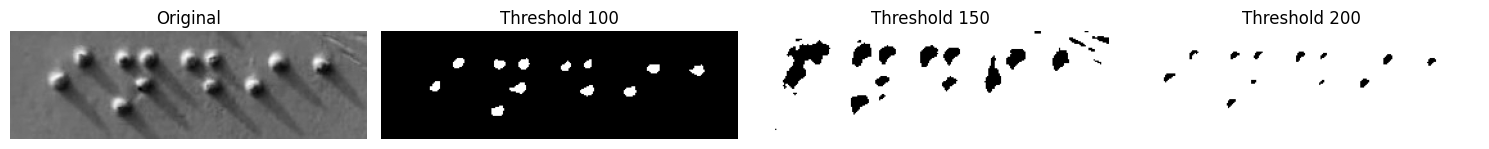

Min pixel value: 74
Max pixel value: 238
Average pixel value: 139.8
Image size: (84, 278)


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def debug_image(image_path):
    img  = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Show original
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    for i, thresh_val in enumerate([100, 150, 200]):
        blur = cv2.GaussianBlur(gray, (3, 3), 0)
        _, thresh = cv2.threshold(blur, thresh_val, 255, cv2.THRESH_BINARY_INV)
        plt.subplot(1, 4, i+2)
        plt.imshow(thresh, cmap="gray")
        plt.title(f"Threshold {thresh_val}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Min pixel value: {gray.min()}")
    print(f"Max pixel value: {gray.max()}")
    print(f"Average pixel value: {gray.mean():.1f}")
    print(f"Image size: {gray.shape}")

debug_image("test.jpeg")

Dots found: 18
Fixed cell size for ALL boxes: 37 x 62
Cells detected: 7
  Cell 1: 3 dots → Letter: J
  Cell 2: 1 dots → Letter: M
  Cell 3: 2 dots → Letter: I
  Cell 4: 3 dots → Letter: H
  Cell 5: 2 dots → Letter: F
  Cell 6: 4 dots → Letter: Q
  Cell 7: 3 dots → Letter: D


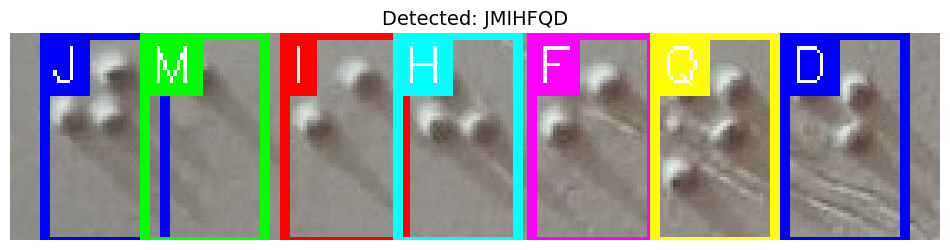


Detected Text: JMIHFQD


In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("model.keras")
classes = [
    'A','B','C','D','E','F','G','H','I',
    'J','K','L','M','N','O','P','Q','R',
    'S','T','U','V','W','X','Y','Z','space'
]

def predict_character(img):
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = img.reshape(1, 64, 64, 1)
    pred = model.predict(img, verbose=0)
    idx = np.argmax(pred)
    return classes[idx]

def read_braille_sentence(image_path):
    img  = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_h, img_w = gray.shape

    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dots = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h > 15:
            dots.append((x, y, w, h))

    if len(dots) == 0:
        print("No dots found!")
        return ""

    print(f"Dots found: {len(dots)}")

    CELL_H = img_h                     
    CELL_W = int(img_h * 0.6)          

    print(f"Fixed cell size for ALL boxes: {CELL_W} x {CELL_H}")

    avg_dot_w    = int(np.mean([w for x,y,w,h in dots]))
    gap_threshold = avg_dot_w * 2
    dots          = sorted(dots, key=lambda d: d[0])

    cells        = []
    current_cell = [dots[0]]

    for i in range(1, len(dots)):
        prev_right = current_cell[-1][0] + current_cell[-1][2]
        curr_left  = dots[i][0]
        gap        = curr_left - prev_right

        if gap > gap_threshold:
            cells.append(current_cell)
            current_cell = [dots[i]]
        else:
            current_cell.append(dots[i])

    cells.append(current_cell)
    print(f"Cells detected: {len(cells)}")

    colors = [
        (255, 0,   0),
        (0,   255, 0),
        (0,   0,   255),
        (255, 255, 0),
        (255, 0,   255),
        (0,   255, 255),
    ]

    img_result = img.copy()
    sentence   = ""

    for i, cell_dots in enumerate(cells):
        cx = int(np.mean([d[0] + d[2]//2 for d in cell_dots]))

        fx1 = max(0,      cx - CELL_W // 2)
        fy1 = 0                              
        fx2 = min(img_w,  cx + CELL_W // 2)
        fy2 = img_h                          

        color    = colors[i % len(colors)]
        char_img = gray[fy1:fy2, fx1:fx2]
        letter   = predict_character(char_img)
        sentence += letter

        cv2.rectangle(img_result, (fx1, fy1), (fx2, fy2), color, 2)

        label = f"{letter}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_result, (fx1, fy1), (fx1+tw+4, fy1+th+6), color, -1)
        cv2.putText(img_result, label, (fx1+2, fy1+th+2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        print(f"  Cell {i+1}: {len(cell_dots)} dots → Letter: {letter}")

    plt.figure(figsize=(12, 4))
    plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected: {sentence}", fontsize=14)
    plt.axis("off")
    plt.show()

    return sentence

result = read_braille_sentence("test.jpeg")
print(f"\nDetected Text: {result}")